**Assignment-6**

Design and implement a Convolutional Neural Network (CNN) for image classification using the Tomato or Soybean disease dataset.

Dataset used: Tomato Leaf Dataset For Disease Detection (from Kaggle)

In [ ]:
# Import core libraries: OS utilities, NumPy/Pandas, plotting, TensorFlow/Keras layers, and sklearn metrics
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
tf.random.set_seed(42)

In [ ]:
# Download the Tomato Leaf disease dataset from Kaggle
import kagglehub
download_path = kagglehub.dataset_download("yusufmurtaza01/tomato-leaf-dataset-for-disease-detection")

# Helper to locate the directory that actually contains the class subfolders
def find_data_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if dirnames and not filenames:
            return dirpath
    return root

data_dir = find_data_dir(download_path)
print("Data directory:", data_dir)
print("Classes:", os.listdir(data_dir))

Using Colab cache for faster access to the 'tomato-leaf-dataset-for-disease-detection' dataset.
Data directory: /kaggle/input/tomato-leaf-dataset-for-disease-detection/tomato_yolo_dataset
Classes: ['labels', 'images']


In [ ]:
# Set target image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Load training split (80%) from the image directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
# Load validation split (20%) from the image directory
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# Extract class names and count
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

# Cache, shuffle, and prefetch datasets to speed up training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


Found 18158 files belonging to 2 classes.
Using 14527 files for training.
Found 18158 files belonging to 2 classes.
Using 3631 files for validation.
Classes (2): ['images', 'labels']


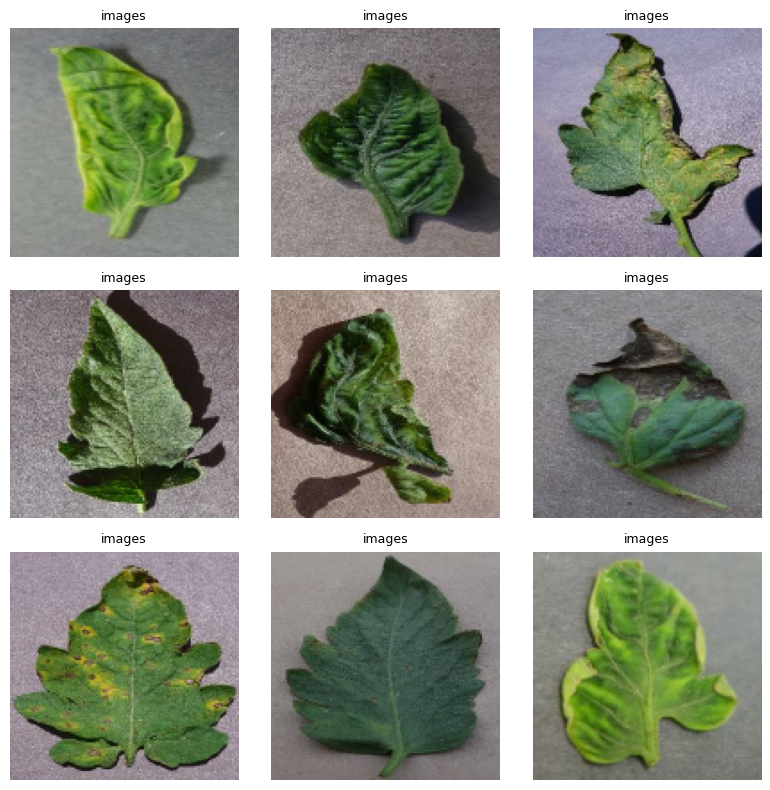

In [ ]:
# Visualize a sample batch of training images with their class labels
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Define data augmentation layers
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# CNN with three convolutional blocks followed by dense layers
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

# Compile with Adam optimizer and sparse categorical crossentropy loss
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

# Instantiate and summarize the model
model = build_cnn_model(IMG_SIZE + (3,), num_classes)
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Stop training early if validation loss doesn't improve, restoring the best weights
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

# Training the model for up to 20 epochs
history = model.fit(
    train_ds, validation_data=val_ds, epochs=20, callbacks=[early_stop]
)

Epoch 1/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.9993 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


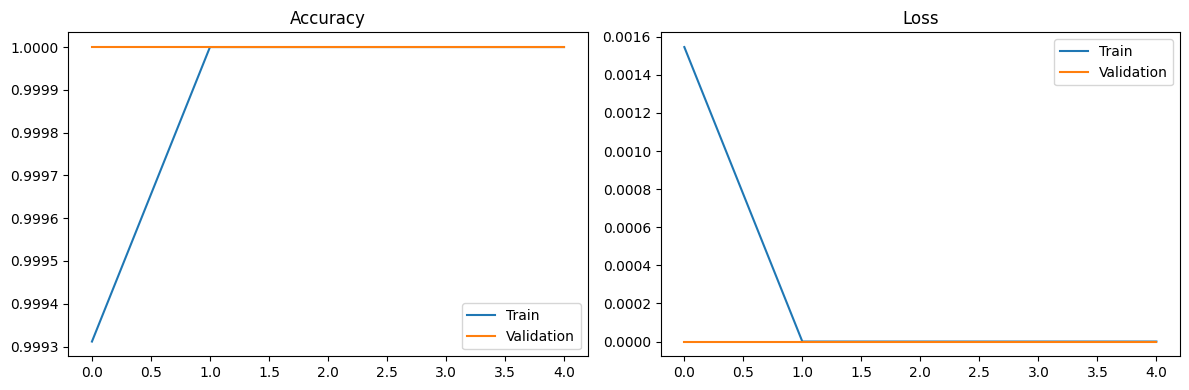

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Validation Accuracy: 1.0000


In [ ]:
# Convert training history to a DataFrame for easy plotting
hist_df = pd.DataFrame(history.history)

# Plot training vs validation accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['accuracy'], label='Train')
axes[0].plot(hist_df['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(hist_df['loss'], label='Train')
axes[1].plot(hist_df['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout()
plt.show()

# Final evaluation on the validation set
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
